# EDA for the NNS files:
- check for missing values
- check what variables we can use

## Load in NNS dataset

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [2]:
data = pd.read_csv('../data/raw/nns_18_19_21/Beatrix Eloise_Tanglao_2026-03-24055951_data-set_anthrop.csv')
# Display the first few rows of the dataset
data.head()

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/737605079.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/raw/nns_18_19_21/Beatrix Eloise_Tanglao_2026-03-24055951_data-set_anthrop.csv')


,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,ethnicity,weight,height,waist,hip,anthro_group,mos_lactation,mos_preg
0,1,1,2019,45958,1,2240.2327,111.251910,10,13,82,0,57.599998,171.850006,69.266670,88.233330,4,NaN,NaN
1,1,1,2019,45958,2,2287.2642,109.743670,10,13,82,0,57.275002,166.250000,68.900002,86.666664,4,NaN,NaN
2,1,1,2019,45958,3,2757.3613,66.695587,10,13,82,0,67.474998,145.449997,NaN,NaN,5,NaN,6.0
3,1,1,2019,45958,4,3146.1538,83.465775,10,13,82,0,13.775000,101.649994,NaN,NaN,1,NaN,NaN
4,1,1,2019,45959,1,2090.6460,71.073441,10,13,82,0,64.224998,172.100006,78.599998,92.166664,4,NaN,NaN


In [3]:
# check unique values in 'enns_year' column
print(data['enns_year'].unique())

# check how many rows have each value in the 'enns_year' column'
print(data['enns_year'].value_counts())

[2019 2021 2018]
enns_year
2019    158230
2018    154969
2021    131201
Name: count, dtype: int64


In [4]:
# count number of rows
num_rows = len(data)
num_rows

444400

In [5]:
# count the number of missing values in each column
missing_values = data.isnull().sum()
missing_values

regcode                0
provhuc                0
enns_year              0
hhnum                  0
member_code            0
fwgti_natl_var         0
fwgti_prov             0
rep_natl               0
rep_prov               0
ms_psucode             0
ethnicity              0
weight               316
height               652
waist             131237
hip               210341
anthro_group           0
mos_lactation     433496
mos_preg          440775
dtype: int64

## Visualize province boundaries

In [6]:
# import the provinces shapefile
provinces = gpd.read_file('../data/raw/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

<Axes: >

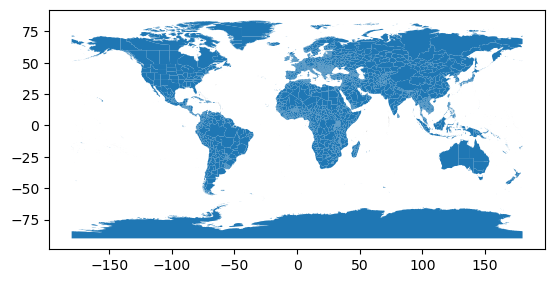

In [7]:
# visualize the province boundaries
provinces.plot()

<Axes: >

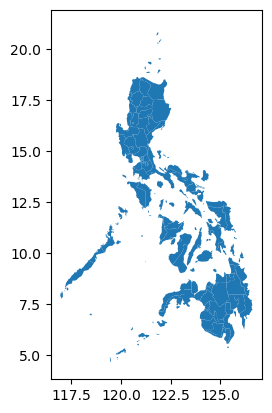

In [8]:
# zoom in on the Philippines
philippines = provinces[provinces['admin'] == 'Philippines']
philippines.plot()

In [9]:
# sanity check: count the number of unique provinces in the Philippines
prov_names_shp = philippines['name']

num_unique_HUC = philippines['name'].nunique()
print(num_unique_HUC)

115


Note: 'provinces' here includes cities. Look at documentation to see how I can access only the provinces

In [10]:
philippines['type']

1821         Lalawigan|Probinsya
1832         Lalawigan|Probinsya
1834         Lalawigan|Probinsya
1835         Lalawigan|Probinsya
1837         Lalawigan|Probinsya
                  ...           
4506       Highly Urbanized City
4507       Highly Urbanized City
4508    Independent Municipality
4509         Lalawigan|Probinsya
4510       Highly Urbanized City
Name: type, Length: 118, dtype: object

In [11]:
# filter for only provinces, not cities or other administrative divisions
philippines_provinces = philippines[philippines['type'] == 'Lalawigan|Probinsya']

<Axes: >

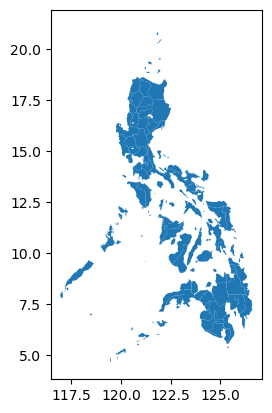

In [12]:
philippines_provinces.plot()

In [13]:
# sanity check: count the number of unique provinces in the Philippines
print(philippines_provinces['name'])
unique_provinces = philippines_provinces['name'].nunique()

1821                 Sulu
1832      Davao del Norte
1834    Zamboanga Sibugay
1835              Palawan
1837    Surigao del Norte
              ...        
4179               Tarlac
4180               Apayao
4181              Kalinga
4182                 Abra
4509     Mandaluyong City
Name: name, Length: 80, dtype: object


## Goal: make sure that all of the labels in the dataset are in the shapefile. Take out any values in the shapefile that aren't in the dataset

Check how much the value_label column in the Province_HUCs and the province labels match

In [14]:
# load in the data dictionary, skipping the lines that have more than 5 columns, then filter
label_dict = pd.read_csv('../data/raw/nns_18_19_21/Beatrix Eloise_Tanglao_2026-03-24055951_data-dictionary_anthrop.csv', 
                        on_bad_lines='skip')

prov_dict = label_dict[label_dict['variable_label'] == 'Province and HUCs Level']
prov_dict

,formno,variable_name,variable_label,var_value,value_label
17,form21_2018,provhuc,Province and HUCs Level,1.0,Ilocos Norte
18,form21_2018,provhuc,Province and HUCs Level,2.0,Ilocos Sur
19,form21_2018,provhuc,Province and HUCs Level,3.0,La Union
20,form21_2018,provhuc,Province and HUCs Level,4.0,Pangasinan
21,form21_2018,provhuc,Province and HUCs Level,5.0,Batanes
...,...,...,...,...,...
128,form21_2018,provhuc,Province and HUCs Level,112.0,Agusan Del Norte
129,form21_2018,provhuc,Province and HUCs Level,113.0,Agusan Del Sur
130,form21_2018,provhuc,Province and HUCs Level,114.0,Surigao Del Norte
131,form21_2018,provhuc,Province and HUCs Level,115.0,Surigao Del Sur


In [15]:
# check which values in prov_dict[value_label] are not in the provinces shapefile (unique_HUC)
prov_dict_values = prov_dict['value_label']
prov_dict_values


17          Ilocos Norte
18            Ilocos Sur
19              La Union
20            Pangasinan
21               Batanes
             ...        
128     Agusan Del Norte
129       Agusan Del Sur
130    Surigao Del Norte
131      Surigao Del Sur
132      Dinagat Islands
Name: value_label, Length: 116, dtype: object

In [16]:
# what values are in prov_dict_values but not in prov_names_shp?
np.setdiff1d(prov_dict_values, prov_names_shp)

array(['Agusan Del Norte', 'Agusan Del Sur', 'Angeles City',
       'Bacolod City', 'Butuan City', 'Cagayan De Oro',
       'Cagayan Province', 'Caloocan City', 'Cebu City',
       'City Of Malabon', 'City Of Marikina', 'City Of Para?aque',
       'City of Isabela', 'City of Manila', 'City of Muntinlupa',
       'City of Navotas', 'City of Pasig', 'City of Valenzuela',
       'Cotabato City', 'Davao City', 'Davao Del Norte', 'Davao Del Sur',
       'Davao Occidental', 'Dinagat Islands', 'General Santos City',
       'Iligan City', 'Iloilo City', 'Iloilo Province',
       'Isabela Province', 'Lanao Del Norte', 'Lanao Del Sur',
       'Lapu-Lapu City (Opon)', 'Las Pi?as City', 'Lucena City',
       'Makati City', 'Mandaue City', 'North Cotabato',
       'Occidental Mindoro', 'Olongapo City', 'Oriental Mindoro',
       'Pasay City', 'Puerto Princesa City', 'Quezon Province',
       'San Juan City', 'Surigao Del Norte', 'Surigao Del Sur',
       'Tacloban City', 'Taguig City', 'Western Sam

In [17]:
# what values are in prov_names_shp but not in prov_dict values?
np.setdiff1d(prov_names_shp, prov_dict_values)

array(['Agusan del Norte', 'Agusan del Sur', 'Angeles', 'Bacolod',
       'Butuan', 'Cagayan', 'Cagayan de Oro', 'Caloocan', 'Cotabato',
       'Dagupan', 'Davao', 'Davao del Norte', 'Davao del Sur',
       'General Santos', 'Iligan', 'Iloilo', 'Isabela', 'Lanao del Norte',
       'Lanao del Sur', 'Lapu-Lapu', 'Las Pinas', 'Lucena', 'Makati',
       'Malabon', 'Mandaue', 'Manila', 'Marikina', 'Mindoro Occidental',
       'Mindoro Oriental', 'Muntinlupa', 'Naga', 'Navotas', 'Olongapo',
       'Ormoc', 'Paranaque', 'Pasay', 'Pasig', 'Puerto Princesa',
       'Quezon', 'Samar', 'San Juan', 'Santiago', 'Sulu',
       'Surigao del Norte', 'Surigao del Sur', 'Tacloban', 'Taguig',
       'Valenzuela', 'Zamboanga', 'Zamboanga del Sur'], dtype=object)

In [18]:
# make all values lowercase for both sets and check again
# what values are in prov_dict_values but not in prov_names_shp?
prov_dict_values_lower = prov_dict_values.str.lower()
prov_names_shp_lower = prov_names_shp.str.lower()
np.setdiff1d(prov_dict_values_lower, prov_names_shp_lower)

array(['angeles city', 'bacolod city', 'butuan city', 'cagayan province',
       'caloocan city', 'cebu city', 'city of isabela', 'city of malabon',
       'city of manila', 'city of marikina', 'city of muntinlupa',
       'city of navotas', 'city of para?aque', 'city of pasig',
       'city of valenzuela', 'cotabato city', 'davao city',
       'davao occidental', 'dinagat islands', 'general santos city',
       'iligan city', 'iloilo city', 'iloilo province',
       'isabela province', 'lapu-lapu city (opon)', 'las pi?as city',
       'lucena city', 'makati city', 'mandaue city', 'north cotabato',
       'occidental mindoro', 'olongapo city', 'oriental mindoro',
       'pasay city', 'puerto princesa city', 'quezon province',
       'san juan city', 'tacloban city', 'taguig city', 'western samar',
       'zamboanga city'], dtype=object)

In [19]:
np.setdiff1d(prov_names_shp_lower, prov_dict_values_lower)

array(['angeles', 'bacolod', 'butuan', 'cagayan', 'caloocan', 'cotabato',
       'dagupan', 'davao', 'general santos', 'iligan', 'iloilo',
       'isabela', 'lapu-lapu', 'las pinas', 'lucena', 'makati', 'malabon',
       'mandaue', 'manila', 'marikina', 'mindoro occidental',
       'mindoro oriental', 'muntinlupa', 'naga', 'navotas', 'olongapo',
       'ormoc', 'paranaque', 'pasay', 'pasig', 'puerto princesa',
       'quezon', 'samar', 'san juan', 'santiago', 'sulu', 'tacloban',
       'taguig', 'valenzuela', 'zamboanga'], dtype=object)

In [20]:
# remove ' city' and 'city of ' from the province names in the dictionary and shapefile and check again
prov_dict_values_cleaned = prov_dict_values_lower.str.replace(' city', '').str.replace('city of ', '')
prov_names_shp_cleaned = prov_names_shp_lower.str.replace(' city', '').str.replace('city of ', '')
np.setdiff1d(prov_dict_values_cleaned, prov_names_shp_lower)

array(['cagayan province', 'davao occidental', 'dinagat islands',
       'iloilo province', 'isabela province', 'lapu-lapu (opon)',
       'las pi?as', 'mandaluyong', 'north cotabato', 'occidental mindoro',
       'oriental mindoro', 'para?aque', 'quezon province',
       'western samar'], dtype=object)

In [21]:
np.setdiff1d(prov_names_shp_cleaned, prov_dict_values_cleaned)

array(['cagayan', 'dagupan', 'lapu-lapu', 'las pinas',
       'mindoro occidental', 'mindoro oriental', 'naga', 'ormoc',
       'paranaque', 'samar', 'santiago', 'sulu'], dtype=object)

Problem with the strategy above: some cities and provinces could have the same name, so removing the city label could result in an inaccurate data pulling

## Analyze provinces first
- for dictionary, anything without the ' city' or 'city of ' label
- for shapefile, anything where the type is 'Lalawigan|Probinsya' 

### Data pre-processing for dictionary

In [22]:
# remove anything with 'city' in the name from the dictionary and display
philippines_provinces_no_cities = prov_dict[~prov_dict['value_label'].str.contains('city', case=False)]
philippines_provinces_no_cities

,formno,variable_name,variable_label,var_value,value_label
17,form21_2018,provhuc,Province and HUCs Level,1.0,Ilocos Norte
18,form21_2018,provhuc,Province and HUCs Level,2.0,Ilocos Sur
19,form21_2018,provhuc,Province and HUCs Level,3.0,La Union
20,form21_2018,provhuc,Province and HUCs Level,4.0,Pangasinan
21,form21_2018,provhuc,Province and HUCs Level,5.0,Batanes
...,...,...,...,...,...
128,form21_2018,provhuc,Province and HUCs Level,112.0,Agusan Del Norte
129,form21_2018,provhuc,Province and HUCs Level,113.0,Agusan Del Sur
130,form21_2018,provhuc,Province and HUCs Level,114.0,Surigao Del Norte
131,form21_2018,provhuc,Province and HUCs Level,115.0,Surigao Del Sur


In [23]:
# make a list for value_label and make the values lowercase
philippines_provinces_no_cities_list = philippines_provinces_no_cities['value_label'].str.lower().tolist()
philippines_provinces_no_cities_list

['ilocos norte',
 'ilocos sur',
 'la union',
 'pangasinan',
 'batanes',
 'cagayan province',
 'isabela province',
 'nueva vizcaya',
 'quirino',
 'bataan',
 'bulacan',
 'nueva ecija',
 'pampanga',
 'tarlac',
 'zambales',
 'aurora',
 'batangas',
 'cavite',
 'laguna',
 'quezon province',
 'rizal',
 'marinduque',
 'occidental mindoro',
 'oriental mindoro',
 'palawan',
 'romblon',
 'albay',
 'camarines norte',
 'camarines sur',
 'catanduanes',
 'masbate',
 'sorsogon',
 'aklan',
 'antique',
 'capiz',
 'iloilo province',
 'negros occidental',
 'guimaras',
 'bohol',
 'cebu',
 'negros oriental',
 'siquijor',
 'eastern samar',
 'leyte',
 'northern samar',
 'western samar',
 'southern leyte',
 'biliran',
 'zamboanga del norte',
 'zamboanga del sur',
 'zamboanga sibugay',
 'bukidnon',
 'camiguin',
 'lanao del norte',
 'misamis occidental',
 'cagayan de oro',
 'misamis oriental',
 'davao del norte',
 'davao del sur',
 'davao oriental',
 'compostela valley',
 'davao occidental',
 'north cotabato',
 

### Data pre-processing for shapefile

In [24]:
# filter shapefile for only rows where the type is 'Lalawigan|Probinsya'
philippines_provinces_shp = philippines[philippines['type'] == 'Lalawigan|Probinsya']
philippines_provinces_shp.head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
1821,Admin-1 states provinces,7,PHL-2524,2524,PH-SLU,http://en.wikipedia.org/wiki/Sulu_(province),PH,4,Sulu,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((120.86069 5.57437, 120.87306 5..."
1832,Admin-1 states provinces,7,PHL-2591,2591,PH-DAV,http://en.wikipedia.org/wiki/Davao_del_Norte,PH,3,Davao del Norte,Davao,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.79127 6.94819, 125.79371 6..."
1834,Admin-1 states provinces,7,PHL-2521,2521,PH-ZSI,http://en.wikipedia.org/wiki/Zamboanga_Sibugay,PH,3,Zamboanga Sibugay,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((122.97169 7.38361, 122.95167 7..."
1835,Admin-1 states provinces,7,PHL-2534,2534,PH-PLW,http://en.wikipedia.org/wiki/Palawan,PH,3,Palawan,Paragua,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((121.25245 9.63117, 121.25685 9..."
1837,Admin-1 states provinces,7,PHL-2593,2593,PH-SUN,http://en.wikipedia.org/wiki/Surigao_del_Norte,PH,4,Surigao del Norte,Dinagat Islands,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.99024 9.68574, 126.00148 9..."


In [25]:
len(philippines_provinces_shp)

80

In [26]:
# make a list of the province names in the shapefile and make them lowercase
philippines_provinces_shp_list = philippines_provinces_shp['name'].str.lower().tolist()
philippines_provinces_shp_list

['sulu',
 'davao del norte',
 'zamboanga sibugay',
 'palawan',
 'surigao del norte',
 'surigao del sur',
 'agusan del norte',
 'misamis oriental',
 'lanao del norte',
 'zamboanga del sur',
 'misamis occidental',
 'zamboanga del norte',
 'lanao del sur',
 'maguindanao',
 'sultan kudarat',
 'sarangani',
 'davao del sur',
 'compostela valley',
 'davao oriental',
 'southern leyte',
 'leyte',
 'eastern samar',
 'biliran',
 'samar',
 'aurora',
 'quezon',
 'camarines norte',
 'camarines sur',
 'albay',
 'sorsogon',
 'batangas',
 'cavite',
 'bulacan',
 'pampanga',
 'bataan',
 'zambales',
 'pangasinan',
 'la union',
 'ilocos sur',
 'ilocos norte',
 'cagayan',
 'isabela',
 'tawi-tawi',
 'basilan',
 'camiguin',
 'siquijor',
 'bohol',
 'guimaras',
 'negros occidental',
 'negros oriental',
 'cebu',
 'aklan',
 'antique',
 'iloilo',
 'capiz',
 'romblon',
 'northern samar',
 'masbate',
 'mindoro oriental',
 'mindoro occidental',
 'marinduque',
 'catanduanes',
 'batanes',
 'agusan del sur',
 'bukidnon'

In [27]:
# check which values in the dictionary list are not in the shapefile list
print(np.setdiff1d(philippines_provinces_no_cities_list, philippines_provinces_shp_list))
# check which values in the shapefile list are not in the dictionary list
print(np.setdiff1d(philippines_provinces_shp_list, philippines_provinces_no_cities_list))

['baguio' 'cagayan de oro' 'cagayan province' 'davao occidental'
 'dinagat islands' 'iloilo province' 'isabela province' 'north cotabato'
 'occidental mindoro' 'oriental mindoro' 'pateros' 'quezon province'
 'western samar']
['cagayan' 'cotabato' 'iloilo' 'isabela' 'mandaluyong city'
 'mindoro occidental' 'mindoro oriental' 'quezon' 'samar' 'sulu']


Notes:
- HUCs, not provinces found in dictionary
    - 'baguio', 'cagayan de oro'
- labels in dictionary that have 'province', but not in the shapefile:
    - 'cagayan province', 'iloilo province', 'isabela province', 'quezon province'
- name switch-ups
    - 'occidental mindoro'/'mindoro occidental'
    - 'oriental mindoro'/'mindoro oriental'
    - 'north cotabato'/'cotabato'
    - 'western samar'/'samar'

## Clean the dictionary and shapefile datasets

1. Make the province names lowercase for both datasets
2. In the shapefile, remove 'city of ' from the names of the items that have it
3. In the dictionary, replace 'city of ' with ' city'
4. In the shapefile, add ' city' if it has the HUC label
5. If a shapefile row is labelled as province and the dictionary name has 'province' in it, add 'province' to the shapefile

Edge cases:
1. Change '?' to 'n' in the dictionary
2. Remove ' opon' in the dictionary
3. Change 'mindoro oriental' in the shapefile to 'oriental mindoro'
4. Change 'mindoro occidental' in the shapefile to 'occidental mindoro'
5. Change 'western samar' in the dictionary to 'samar'

### View datasets

In [28]:
# view nns dataset
data.head()

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,ethnicity,weight,height,waist,hip,anthro_group,mos_lactation,mos_preg
0,1,1,2019,45958,1,2240.2327,111.251910,10,13,82,0,57.599998,171.850006,69.266670,88.233330,4,NaN,NaN
1,1,1,2019,45958,2,2287.2642,109.743670,10,13,82,0,57.275002,166.250000,68.900002,86.666664,4,NaN,NaN
2,1,1,2019,45958,3,2757.3613,66.695587,10,13,82,0,67.474998,145.449997,NaN,NaN,5,NaN,6.0
3,1,1,2019,45958,4,3146.1538,83.465775,10,13,82,0,13.775000,101.649994,NaN,NaN,1,NaN,NaN
4,1,1,2019,45959,1,2090.6460,71.073441,10,13,82,0,64.224998,172.100006,78.599998,92.166664,4,NaN,NaN


In [29]:
# view dictionary dataset provinces and HUCs level
prov_dict.head()

,formno,variable_name,variable_label,var_value,value_label
17,form21_2018,provhuc,Province and HUCs Level,1.0,Ilocos Norte
18,form21_2018,provhuc,Province and HUCs Level,2.0,Ilocos Sur
19,form21_2018,provhuc,Province and HUCs Level,3.0,La Union
20,form21_2018,provhuc,Province and HUCs Level,4.0,Pangasinan
21,form21_2018,provhuc,Province and HUCs Level,5.0,Batanes


In [30]:
# view shapefile dataset
philippines.head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
1821,Admin-1 states provinces,7,PHL-2524,2524,PH-SLU,http://en.wikipedia.org/wiki/Sulu_(province),PH,4,Sulu,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((120.86069 5.57437, 120.87306 5..."
1832,Admin-1 states provinces,7,PHL-2591,2591,PH-DAV,http://en.wikipedia.org/wiki/Davao_del_Norte,PH,3,Davao del Norte,Davao,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.79127 6.94819, 125.79371 6..."
1834,Admin-1 states provinces,7,PHL-2521,2521,PH-ZSI,http://en.wikipedia.org/wiki/Zamboanga_Sibugay,PH,3,Zamboanga Sibugay,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((122.97169 7.38361, 122.95167 7..."
1835,Admin-1 states provinces,7,PHL-2534,2534,PH-PLW,http://en.wikipedia.org/wiki/Palawan,PH,3,Palawan,Paragua,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((121.25245 9.63117, 121.25685 9..."
1837,Admin-1 states provinces,7,PHL-2593,2593,PH-SUN,http://en.wikipedia.org/wiki/Surigao_del_Norte,PH,4,Surigao del Norte,Dinagat Islands,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.99024 9.68574, 126.00148 9..."


### Basic Data Cleaning

In [31]:
# make the province names in the dictionary lowercase
prov_dict['value_label_lower'] = prov_dict['value_label'].str.lower()
prov_dict.head()

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/1405361016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower'] = prov_dict['value_label'].str.lower()


,formno,variable_name,variable_label,var_value,value_label,value_label_lower
17,form21_2018,provhuc,Province and HUCs Level,1.0,Ilocos Norte,ilocos norte
18,form21_2018,provhuc,Province and HUCs Level,2.0,Ilocos Sur,ilocos sur
19,form21_2018,provhuc,Province and HUCs Level,3.0,La Union,la union
20,form21_2018,provhuc,Province and HUCs Level,4.0,Pangasinan,pangasinan
21,form21_2018,provhuc,Province and HUCs Level,5.0,Batanes,batanes


In [32]:
# make the province names in the shapefile lowercase
philippines['name_lower'] = philippines['name'].str.lower()
philippines.head()

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry,name_lower
1821,Admin-1 states provinces,7,PHL-2524,2524,PH-SLU,http://en.wikipedia.org/wiki/Sulu_(province),PH,4,Sulu,None,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((120.86069 5.57437, 120.87306 5...",sulu
1832,Admin-1 states provinces,7,PHL-2591,2591,PH-DAV,http://en.wikipedia.org/wiki/Davao_del_Norte,PH,3,Davao del Norte,Davao,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.79127 6.94819, 125.79371 6...",davao del norte
1834,Admin-1 states provinces,7,PHL-2521,2521,PH-ZSI,http://en.wikipedia.org/wiki/Zamboanga_Sibugay,PH,3,Zamboanga Sibugay,None,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((122.97169 7.38361, 122.95167 7...",zamboanga sibugay
1835,Admin-1 states provinces,7,PHL-2534,2534,PH-PLW,http://en.wikipedia.org/wiki/Palawan,PH,3,Palawan,Paragua,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((121.25245 9.63117, 121.25685 9...",palawan
1837,Admin-1 states provinces,7,PHL-2593,2593,PH-SUN,http://en.wikipedia.org/wiki/Surigao_del_Norte,PH,4,Surigao del Norte,Dinagat Islands,...,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((125.99024 9.68574, 126.00148 9...",surigao del norte


In [33]:
# in the shapefile, remove ' city' and 'city of ' from the province names
philippines['name_lower_cleaned'] = philippines['name_lower'].str.replace(' city', '').str.replace('city of ', '')

# in the shapefile, if the type is 'Highly Urbanized City', add ' city' to the end of the name
philippines['name_lower_cleaned'] = np.where(philippines['type'] == 'Highly Urbanized City', 
                                                philippines['name_lower_cleaned'] + ' city', 
                                                philippines['name_lower_cleaned'])

philippines['name_lower_cleaned']

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


1821                 sulu
1832      davao del norte
1834    zamboanga sibugay
1835              palawan
1837    surigao del norte
              ...        
4506          baguio city
4507          makati city
4508              pateros
4509          mandaluyong
4510        san juan city
Name: name_lower_cleaned, Length: 118, dtype: object

In [34]:
# in the dictionary, replace 'city of ' at the start with ' city' at the end
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower'].str.replace(r'^city of (.+)', r'\1 city', regex=True)
prov_dict['value_label_lower_cleaned']

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/4249862045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower'].str.replace(r'^city of (.+)', r'\1 city', regex=True)


17          ilocos norte
18            ilocos sur
19              la union
20            pangasinan
21               batanes
             ...        
128     agusan del norte
129       agusan del sur
130    surigao del norte
131      surigao del sur
132      dinagat islands
Name: value_label_lower_cleaned, Length: 116, dtype: object

In [35]:
# If a shapefile row is labelled as Lalawigan|Probinsya and the same name in the dictionary has ' province' in it, add ' province' to the shapefile

# get the set of shapefile names that appear in the dictionary with ' province'
names_with_province = set()

for name in philippines['name_lower_cleaned'].unique():
    match = prov_dict[
        prov_dict['value_label_lower_cleaned'].str.contains(name, case=False, na=False) &
        prov_dict['value_label_lower_cleaned'].str.contains(' province', case=False, na=False)
    ]
    if not match.empty:
        names_with_province.add(name)

# now apply the label only to Lalawigan|Probinsya rows whose name appears in that set
philippines['name_lower_cleaned'] = np.where(
    (philippines['type'] == 'Lalawigan|Probinsya') & 
    (philippines['name_lower_cleaned'].isin(names_with_province)) &
    (~philippines['name_lower_cleaned'].str.contains(' province', case=False, na=False)),  # not already has ' province'
    philippines['name_lower_cleaned'] + ' province',
    philippines['name_lower_cleaned']
)

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [36]:
philippines['name_lower_cleaned']

1821                 sulu
1832      davao del norte
1834    zamboanga sibugay
1835              palawan
1837    surigao del norte
              ...        
4506          baguio city
4507          makati city
4508              pateros
4509          mandaluyong
4510        san juan city
Name: name_lower_cleaned, Length: 118, dtype: object

In [37]:
# check if there are words in the shapefile with the string ' province'
philippines[philippines['name_lower_cleaned'].str.contains(' province')]['name_lower_cleaned']

1990      quezon province
2013     cagayan province
2014     isabela province
3016      iloilo province
4178    mountain province
Name: name_lower_cleaned, dtype: object

In [38]:
# check which values in the dictionary list have the word province in them
prov_dict[prov_dict['value_label_lower_cleaned'].str.contains(' province')]['value_label_lower_cleaned']

22      cagayan province
23      isabela province
38       quezon province
57       iloilo province
121    mountain province
Name: value_label_lower_cleaned, dtype: object

### Edge Cases
1. Change '?' to 'n' in the dictionary
2. Remove ' (opon)' in the dictionary
3. Change 'mindoro oriental' in the shapefile to 'oriental mindoro'
4. Change 'mindoro occidental' in the shapefile to 'occidental mindoro'
5. Change 'western samar' in the dictionary to 'samar'

In [39]:
# Change '?' to 'n' in prov_dict['value_label_lower_cleaned']
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('?', 'n')

# Check if any values in prov_dict['value_label_lower_cleaned'] still contain '?'
prov_dict[prov_dict['value_label_lower_cleaned'].str.contains('?', regex=False)]['value_label_lower_cleaned']

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/1404459491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('?', 'n')


Series([], Name: value_label_lower_cleaned, dtype: object)

In [40]:
# Remove ' (opon)' in the dictionary
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace(' \(opon\)', '', regex=True)

# Check if any values in prov_dict['value_label_lower_cleaned'] still contain '(opon)'
prov_dict[prov_dict['value_label_lower_cleaned'].str.contains('\(opon\)', regex=True)]['value_label_lower_cleaned']

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/4011302686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace(' \(opon\)', '', regex=True)


Series([], Name: value_label_lower_cleaned, dtype: object)

In [41]:
# Change 'mindoro oriental' in the shapefile to 'oriental mindoro'
philippines['name_lower_cleaned'] = philippines['name_lower_cleaned'].str.replace('mindoro oriental', 'oriental mindoro')
# Check if any values in the shapefile still contain 'mindoro oriental'
philippines[philippines['name_lower_cleaned'].str.contains('mindoro oriental')]['name_lower_cleaned']

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Series([], Name: name_lower_cleaned, dtype: object)

In [42]:
# Change 'mindoro occidental' in the shapefile to 'occidental mindoro'
philippines['name_lower_cleaned'] = philippines['name_lower_cleaned'].str.replace('mindoro occidental', 'occidental mindoro')
# Check if any values in the shapefile still contain 'mindoro occidental'
philippines[philippines['name_lower_cleaned'].str.contains('mindoro occidental')]['name_lower_cleaned']

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Series([], Name: name_lower_cleaned, dtype: object)

In [43]:
# Change 'western samar' in the dictionary to 'samar'
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('western samar', 'samar')
# Check if any values in the dictionary still contain 'western samar'
prov_dict[prov_dict['value_label_lower_cleaned'].str.contains('western samar')]['value_label_lower_cleaned']

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/631889726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('western samar', 'samar')


Series([], Name: value_label_lower_cleaned, dtype: object)

In [44]:
# Check which values in the dictionary list are not in the shapefile list
print(np.setdiff1d(prov_dict['value_label_lower_cleaned'], philippines['name_lower_cleaned']))

['baguio' 'cagayan de oro' 'cotabato city' 'davao occidental'
 'dinagat islands' 'isabela city' 'mandaluyong city' 'north cotabato']


In [45]:
# Check which values in the shapefile list are not in the dictionary list
print(np.setdiff1d(philippines['name_lower_cleaned'], prov_dict['value_label_lower_cleaned']))

['baguio city' 'cagayan de oro city' 'cotabato' 'dagupan' 'mandaluyong'
 'naga' 'ormoc' 'santiago' 'sulu']


Google what the problems with these are and then fix them
- cities: baguio, cagayan de oro, cotabato city, isabela city, mandaluyong, north cotabato (just cotabato)
- provinces: davao occidental, dinagat islands

### Check issues

In [46]:
# check type values of the philippines dataset for cotabato
philippines[philippines['name_lower_cleaned'].str.contains('cotabato')][['name_lower_cleaned', 'type']]

,name_lower_cleaned,type
1851,cotabato,Independent Component City
3567,cotabato,Lalawigan|Probinsya
3568,south cotabato,Lalawigan|Probinsya


In [47]:
# check type values of the philippines dataset for mandaluyong
philippines[philippines['name_lower_cleaned'].str.contains('mandaluyong')][['name_lower_cleaned', 'type']]

,name_lower_cleaned,type
4509,mandaluyong,Lalawigan|Probinsya


In [48]:
# check unique type values of the philippines dataset
philippines['type'].unique()

array(['Lalawigan|Probinsya', 'Highly Urbanized City',
       'Independent Component City', 'Independent Municipality'],
      dtype=object)

In [49]:
# check which values in the philippines dataset have the type 'Independent Component City'
philippines[philippines['type'] == 'Independent Component City']['name_lower_cleaned']

1851    cotabato
2009     dagupan
3013       ormoc
4174    santiago
4504        naga
Name: name_lower_cleaned, dtype: object

In [50]:
# check if the shapefile has any row with 'dinagat' in the name
philippines[philippines['name_lower_cleaned'].str.contains('dinagat')]['name_lower_cleaned']

Series([], Name: name_lower_cleaned, dtype: object)

In [51]:
# check if the shapefile has any rows with 'isabela' in the name
philippines[philippines['name_lower_cleaned'].str.contains('isabela')]['name_lower_cleaned']

2014    isabela province
Name: name_lower_cleaned, dtype: object

### Fix remaining issues
- add 'city' to the end of any items in the shapefile that have the type 'Independent Component City'
- change 'baguio' in the dictionary to 'baguio city'
- change 'cagayan de oro' in the dictionary to 'cagayan de oro city'
- change 'north cotabato' in the dictionary to 'cotabato province'
- change 'cotabato' in the shapefile to 'cotabato province' if the row has the type 'Lalawigan|Probinsya'

In [52]:
# add 'city' to the end of any items in the shapefile that have the type 'Independent Component City'
philippines['name_lower_cleaned'] = np.where(
    philippines['type'] == 'Independent Component City',
    philippines['name_lower_cleaned'] + ' city',
    philippines['name_lower_cleaned']
)

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [53]:
# change 'baguio' in the dictionary to 'baguio city'
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('baguio', 'baguio city')

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/4032575432.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('baguio', 'baguio city')


In [54]:
# change 'cagayan de oro' in the dictionary to 'cagayan de oro city'
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('cagayan de oro', 'cagayan de oro city')

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/1266977455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('cagayan de oro', 'cagayan de oro city')


In [55]:
# change 'north cotabato' in the dictionary to 'cotabato province'
prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('north cotabato', 'cotabato province')

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/4066662012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['value_label_lower_cleaned'] = prov_dict['value_label_lower_cleaned'].str.replace('north cotabato', 'cotabato province')


In [56]:
# change 'cotabato' in the shapefile to 'cotabato province' if the row has the type 'Lalawigan|Probinsya'
philippines['name_lower_cleaned'] = np.where(
    (philippines['name_lower_cleaned'] == 'cotabato') & 
    (philippines['type'] == 'Lalawigan|Probinsya'),
    'cotabato province',
    philippines['name_lower_cleaned']
)

### Last check
- these ones will just be taken out in the first analysis

In [57]:
# Check which values in the dictionary list are not in the shapefile list
print(np.setdiff1d(prov_dict['value_label_lower_cleaned'], philippines['name_lower_cleaned']))

['davao occidental' 'dinagat islands' 'isabela city' 'mandaluyong city']


In [58]:
# Check which values in the shapefile list are not in the dictionary list
print(np.setdiff1d(philippines['name_lower_cleaned'], prov_dict['value_label_lower_cleaned']))

['dagupan city' 'mandaluyong' 'naga city' 'ormoc city' 'santiago city'
 'sulu']


## Join the datasets (yay)!
- join prov_dict with the actual nns data on number
- join the super nns dataset with the shapefile on name of the province

### View newly cleaned datasets

In [59]:
prov_dict[['value_label', 'value_label_lower_cleaned']]

,value_label,value_label_lower_cleaned
17,Ilocos Norte,ilocos norte
18,Ilocos Sur,ilocos sur
19,La Union,la union
20,Pangasinan,pangasinan
21,Batanes,batanes
...,...,...
128,Agusan Del Norte,agusan del norte
129,Agusan Del Sur,agusan del sur
130,Surigao Del Norte,surigao del norte
131,Surigao Del Sur,surigao del sur


In [60]:
philippines[['name', 'name_lower_cleaned']]

,name,name_lower_cleaned
1821,Sulu,sulu
1832,Davao del Norte,davao del norte
1834,Zamboanga Sibugay,zamboanga sibugay
1835,Palawan,palawan
1837,Surigao del Norte,surigao del norte
...,...,...
4506,Baguio,baguio city
4507,Makati,makati city
4508,Pateros,pateros
4509,Mandaluyong City,mandaluyong


In [61]:
# check data type of var_value in the dictionary
prov_dict['var_value'].dtype

dtype('float64')

In [62]:
# check data type of provhuc in nns dataset
data['provhuc'].dtype

dtype('int64')

In [63]:
# convert the var_value column in the dictionary to int64
prov_dict['var_value_int'] = pd.to_numeric(prov_dict['var_value'], errors='coerce').astype('Int64')

/var/folders/6j/6prg81m16mj3jnfd_9c5jcjr0000gn/T/ipykernel_62572/961728434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prov_dict['var_value_int'] = pd.to_numeric(prov_dict['var_value'], errors='coerce').astype('Int64')


In [64]:
# view columns 'var_value', 'var_value_int', and 'value_label_lower_cleaned' in the dictionary
prov_dict[['var_value', 'var_value_int', 'value_label_lower_cleaned']]

,var_value,var_value_int,value_label_lower_cleaned
17,1.0,1,ilocos norte
18,2.0,2,ilocos sur
19,3.0,3,la union
20,4.0,4,pangasinan
21,5.0,5,batanes
...,...,...,...
128,112.0,112,agusan del norte
129,113.0,113,agusan del sur
130,114.0,114,surigao del norte
131,115.0,115,surigao del sur


In [65]:
# join prov_dict with the actual nns data on number
data_with_prov = data.merge(prov_dict[['var_value_int', 'value_label_lower_cleaned']], left_on='provhuc', right_on='var_value_int', how='left')
data_with_prov

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,ethnicity,weight,height,waist,hip,anthro_group,mos_lactation,mos_preg,var_value_int,value_label_lower_cleaned
0,1,1,2019,45958,1,2240.2327,111.251910,10,13,82,0,57.599998,171.850006,69.266670,88.233330,4,NaN,NaN,1,ilocos norte
1,1,1,2019,45958,2,2287.2642,109.743670,10,13,82,0,57.275002,166.250000,68.900002,86.666664,4,NaN,NaN,1,ilocos norte
2,1,1,2019,45958,3,2757.3613,66.695587,10,13,82,0,67.474998,145.449997,NaN,NaN,5,NaN,6.0,1,ilocos norte
3,1,1,2019,45958,4,3146.1538,83.465775,10,13,82,0,13.775000,101.649994,NaN,NaN,1,NaN,NaN,1,ilocos norte
4,1,1,2019,45959,1,2090.6460,71.073441,10,13,82,0,64.224998,172.100006,78.599998,92.166664,4,NaN,NaN,1,ilocos norte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444395,42,30,2021,143528,1,1412.1458,36.870472,21,12,201,0,56.724998,162.750000,78.666664,NaN,4,NaN,NaN,30,romblon
444396,42,30,2021,143528,2,1750.8324,74.659164,21,12,201,0,70.324997,152.500000,93.933334,NaN,4,NaN,NaN,30,romblon
444397,42,30,2021,143528,3,1753.3671,34.516403,21,12,201,0,39.400002,145.850006,NaN,NaN,3,NaN,NaN,30,romblon
444398,42,30,2021,143529,1,1896.3191,40.408787,21,12,201,0,77.525002,171.500000,92.800003,NaN,4,NaN,NaN,30,romblon


In [66]:
# join data_with_prov with the shapefile on the province name
final_data = data_with_prov.merge(philippines[['name_lower_cleaned', 'geometry']], left_on='value_label_lower_cleaned', right_on='name_lower_cleaned', how='left')

In [67]:
final_data.head()

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,...,height,waist,hip,anthro_group,mos_lactation,mos_preg,var_value_int,value_label_lower_cleaned,name_lower_cleaned,geometry
0,1,1,2019,45958,1,2240.2327,111.251910,10,13,82,...,171.850006,69.266670,88.233330,4,NaN,NaN,1,ilocos norte,ilocos norte,"POLYGON ((120.42614 17.89404, 120.4253 17.9024..."
1,1,1,2019,45958,2,2287.2642,109.743670,10,13,82,...,166.250000,68.900002,86.666664,4,NaN,NaN,1,ilocos norte,ilocos norte,"POLYGON ((120.42614 17.89404, 120.4253 17.9024..."
2,1,1,2019,45958,3,2757.3613,66.695587,10,13,82,...,145.449997,NaN,NaN,5,NaN,6.0,1,ilocos norte,ilocos norte,"POLYGON ((120.42614 17.89404, 120.4253 17.9024..."
3,1,1,2019,45958,4,3146.1538,83.465775,10,13,82,...,101.649994,NaN,NaN,1,NaN,NaN,1,ilocos norte,ilocos norte,"POLYGON ((120.42614 17.89404, 120.4253 17.9024..."
4,1,1,2019,45959,1,2090.6460,71.073441,10,13,82,...,172.100006,78.599998,92.166664,4,NaN,NaN,1,ilocos norte,ilocos norte,"POLYGON ((120.42614 17.89404, 120.4253 17.9024..."


In [68]:
# add bmi column to final_data by calculating weight in kg divided by height in m squared
final_data['bmi'] = final_data['weight'] / (final_data['height'] / 100) ** 2
final_data[['weight', 'height', 'bmi']]

,weight,height,bmi
0,57.599998,171.850006,19.503986
1,57.275002,166.250000,20.722483
2,67.474998,145.449997,31.894474
3,13.775000,101.649994,13.331434
4,64.224998,172.100006,21.684146
...,...,...,...
444395,56.724998,162.750000,21.415711
444396,70.324997,152.500000,30.239182
444397,39.400002,145.850006,18.521806
444398,77.525002,171.500000,26.358066


In [69]:
# check what percentage of rows in final_data have a null weight
num_null_weights = final_data['weight'].isnull().sum()
total_rows = len(final_data)
percentage_null_weights = (num_null_weights / total_rows) * 100
percentage_null_weights

np.float64(0.0711071107110711)

In [70]:
# check what percentage of rows in final_data have a null height
num_null_heights = final_data['height'].isnull().sum()
total_rows = len(final_data)
percentage_null_heights = (num_null_heights / total_rows) * 100
percentage_null_heights

np.float64(0.1467146714671467)

In [71]:
# check what percentage of rows in final_data have a null bmi
num_null_bmi = final_data['bmi'].isnull().sum()
total_rows = len(final_data)
percentage_null_bmi = (num_null_bmi / total_rows) * 100
percentage_null_bmi

np.float64(0.19779477947794777)

In [72]:
# check what percentage of rows in final_data have a null geometry
num_null_geometry = final_data['geometry'].isnull().sum()
total_rows = len(final_data)
percentage_null_geometry = (num_null_geometry / total_rows) * 100
percentage_null_geometry

np.float64(2.5265526552655264)

In [73]:
total_rows

444400

In [74]:
# export final_data to a csv file
final_data.to_csv('../data/processed/only_nns_18_19_21_cleaned.csv', index=False)

In [75]:
# inspect the final data geometry type
final_data['geometry'][0].geom_type

'Polygon'